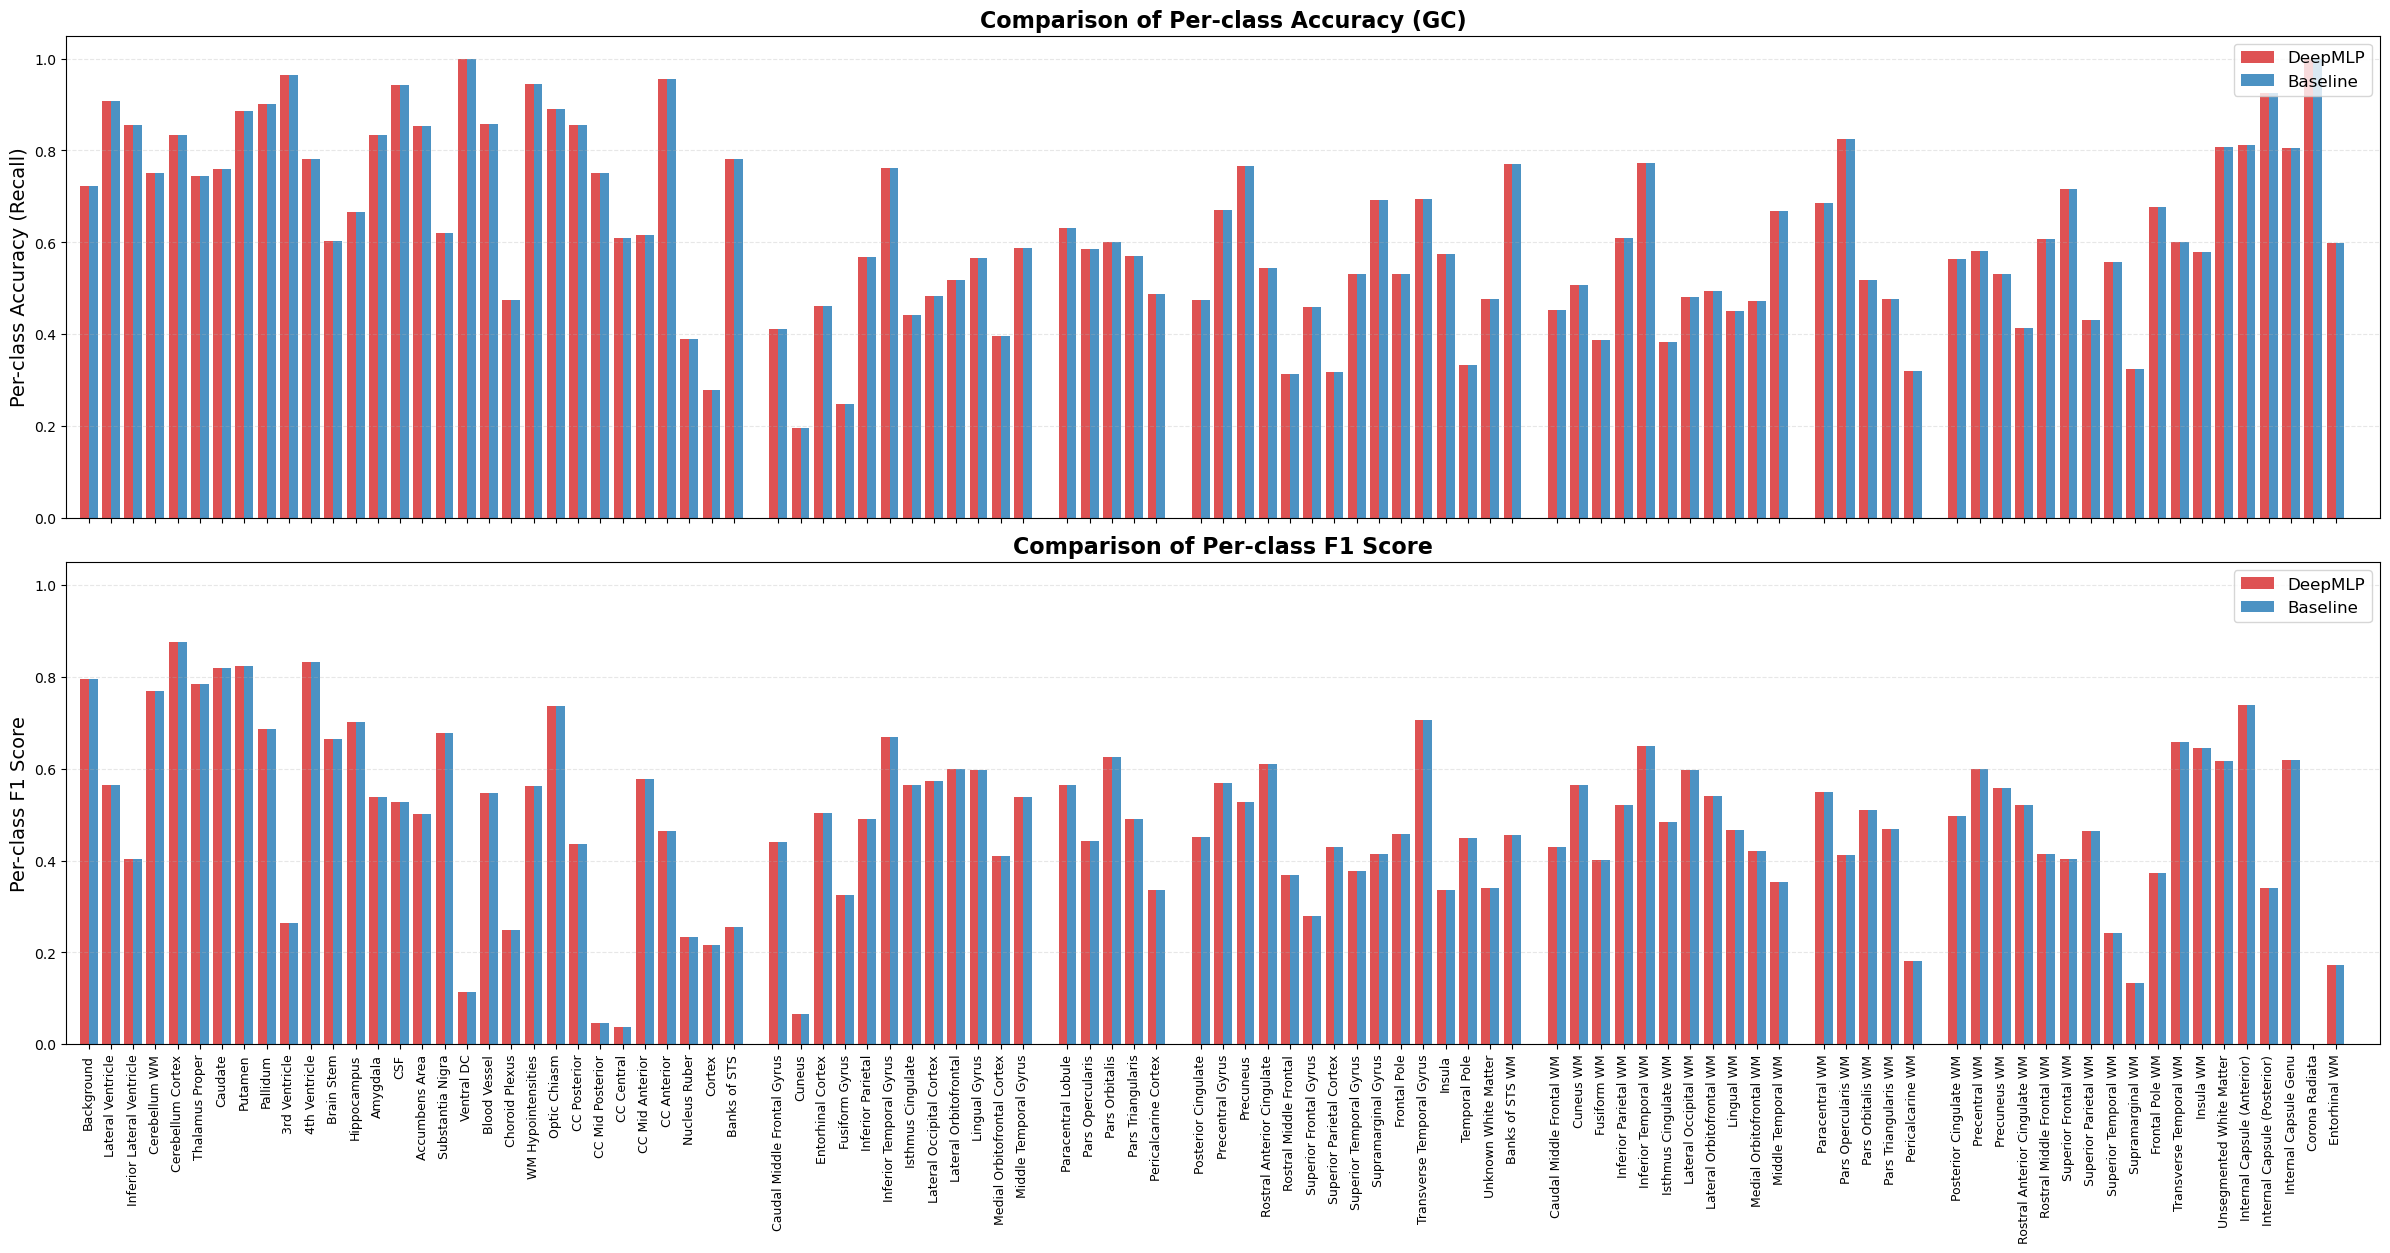

图表已生成: fig3_4_comparison_named.png


In [7]:
import re
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. 完整的解剖学名称字典 (基于你的 Manual Override + CSV 补全清洗)
# ---------------------------------------------------------
class_names = {
    # --- Subcortical & General ---
    0: "Background",
    1: "Lateral Ventricle",
    2: "Inferior Lateral Ventricle",
    3: "Cerebellum WM",
    4: "Cerebellum Cortex",
    5: "Thalamus Proper",
    6: "Caudate",
    7: "Putamen",
    8: "Pallidum",
    9: "3rd Ventricle",
    10: "4th Ventricle",
    11: "Brain Stem",
    12: "Hippocampus",
    13: "Amygdala",
    14: "CSF",
    15: "Accumbens Area",
    16: "Substantia Nigra",
    17: "Ventral DC",
    18: "Blood Vessel",
    19: "Choroid Plexus",
    20: "WM Hypointensities",
    21: "Optic Chiasm",
    22: "CC Posterior",
    23: "CC Mid Posterior",
    24: "CC Central",
    25: "CC Mid Anterior",
    26: "CC Anterior",
    27: "Nucleus Ruber",
    
    # --- Cortex (Grey Matter) ---
    28: "Cortex",
    29: "Banks of STS",
    30: "Caudal Anterior Cingulate",
    31: "Caudal Middle Frontal Gyrus",
    32: "Cuneus",
    33: "Entorhinal Cortex",
    34: "Fusiform Gyrus",
    35: "Inferior Parietal",
    36: "Inferior Temporal Gyrus",
    37: "Isthmus Cingulate",
    38: "Lateral Occipital Cortex",
    39: "Lateral Orbitofrontal",
    40: "Lingual Gyrus",
    41: "Medial Orbitofrontal Cortex",
    42: "Middle Temporal Gyrus",
    43: "Parahippocampal Gyrus",
    44: "Paracentral Lobule",
    45: "Pars Opercularis",
    46: "Pars Orbitalis",
    47: "Pars Triangularis",
    48: "Pericalcarine Cortex",
    49: "Postcentral Gyrus",
    50: "Posterior Cingulate",
    51: "Precentral Gyrus",
    52: "Precuneus",
    53: "Rostral Anterior Cingulate",
    54: "Rostral Middle Frontal",
    55: "Superior Frontal Gyrus",
    56: "Superior Parietal Cortex",
    57: "Superior Temporal Gyrus",
    58: "Supramarginal Gyrus",
    59: "Frontal Pole",
    60: "Transverse Temporal Gyrus",
    61: "Insula",
    62: "Temporal Pole",
    
    # --- White Matter (Subcortical & Deep) ---
    63: "Unknown White Matter",
    64: "Banks of STS WM",
    65: "Caudal Anterior Cingulate WM",
    66: "Caudal Middle Frontal WM",
    67: "Cuneus WM",
    68: "Fusiform WM",
    69: "Inferior Parietal WM",
    70: "Inferior Temporal WM",
    71: "Isthmus Cingulate WM",
    72: "Lateral Occipital WM",
    73: "Lateral Orbitofrontal WM",
    74: "Lingual WM",
    75: "Medial Orbitofrontal WM",
    76: "Middle Temporal WM",
    77: "Parahippocampal WM",
    78: "Paracentral WM",
    79: "Pars Opercularis WM",
    80: "Pars Orbitalis WM",
    81: "Pars Triangularis WM",
    82: "Pericalcarine WM",
    83: "Postcentral WM",
    84: "Posterior Cingulate WM",
    85: "Precentral WM",
    86: "Precuneus WM",
    87: "Rostral Anterior Cingulate WM",
    88: "Rostral Middle Frontal WM",
    89: "Superior Frontal WM",
    90: "Superior Parietal WM",
    91: "Superior Temporal WM",
    92: "Supramarginal WM",
    93: "Frontal Pole WM",
    94: "Transverse Temporal WM",
    95: "Insula WM",
    96: "Unsegmented White Matter",
    97: "Internal Capsule (Anterior)",
    98: "Internal Capsule (Posterior)",
    99: "Internal Capsule Genu",
    100: "Corona Radiata",
    101: "Entorhinal WM"
}

# ---------------------------------------------------------
# 2. 数据解析与绘图代码
# ---------------------------------------------------------

# 文件路径 (请修改为你本地的实际路径)
file_path = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/图3.4  gc f1 history/deepmlptest_evaluation_report.txt'


def parse_report_full(filename):
    data = {'ids': [], 'recall': [], 'f1': []}
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            text = f.read()
        start_marker = "每个类别的详细指标:"
        idx = text.find(start_marker)
        if idx != -1:
            table_text = text[idx:]
            # 正则匹配: ID, Count, Precision, Recall, F1
            pattern = re.compile(r"^\s*(\d+)\s+\d+\s+[0-9\.]+\S*\s+([0-9\.]+)\S*\s+([0-9\.]+)", re.MULTILINE)
            matches = pattern.findall(table_text)
            for pid, rec, f1 in matches:
                data['ids'].append(int(pid))
                data['recall'].append(float(rec))
                data['f1'].append(float(f1))
    except FileNotFoundError:
        print(f"错误: 找不到文件 {filename}")
        return {}
    return data

# 加载数据
deepmlp_data = parse_report_full(file_path)

if not deepmlp_data:
    print("未能读取数据。")
else:
    # 占位符 Baseline 数据 (复制 DeepMLP，实际请替换为真实 Baseline 文件读取)
    baseline_data = deepmlp_data.copy() 

    # 准备绘图数据
    ids = np.array(deepmlp_data['ids'])
    # 将 ID 映射为名字列表
    names = [class_names.get(i, str(i)) for i in ids]
    
    width = 0.4
    
    # 设置超宽画布以容纳 102 个名字
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 14), sharex=True)
    
    # --- 上图: Per-class GC (Recall) ---
    ax1.bar(ids - width/2, deepmlp_data['recall'], width, label='DeepMLP', color='#d62728', alpha=0.8)
    ax1.bar(ids + width/2, baseline_data['recall'], width, label='Baseline', color='#1f77b4', alpha=0.8)
    
    ax1.set_ylabel('Per-class Accuracy (Recall)', fontsize=14)
    ax1.set_title('Comparison of Per-class Accuracy (GC)', fontsize=16, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    ax1.set_ylim(0, 1.05)
    # 移除上图的 X 轴刻度标签，避免重复
    plt.setp(ax1.get_xticklabels(), visible=False)

    # --- 下图: Per-class F1 Score ---
    ax2.bar(ids - width/2, deepmlp_data['f1'], width, label='DeepMLP', color='#d62728', alpha=0.8)
    ax2.bar(ids + width/2, baseline_data['f1'], width, label='Baseline', color='#1f77b4', alpha=0.8)

    ax2.set_ylabel('Per-class F1 Score', fontsize=14)
    ax2.set_title('Comparison of Per-class F1 Score', fontsize=16, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=12)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
    ax2.set_ylim(0, 1.05)
    
    # 设置 X 轴: 显示所有 102 个名字，旋转 90 度
    ax2.set_xticks(ids)
    ax2.set_xticklabels(names, rotation=90, fontsize=9, ha='center')
    ax2.set_xlim(-1, 103)

    plt.tight_layout()
    # 调整底部边距，给名字留出足够空间
    plt.subplots_adjust(bottom=0.25)
    
    save_path = 'fig3_4_comparison_named.png'
    # plt.savefig(save_path, dpi=300)
    plt.show()
    
    print(f"图表已生成: {save_path}")

✅ 选定的 Baseline Fold: per_class_metrics_test32.json
✅ Baseline Macro-F1: 0.4391 (目标: 0.438)
✅ DeepMLP 数据读取成功，包含 96 个类别


/var/folders/kr/c215w16n7756009kd5l3llzm0000gn/T/ipykernel_8313/544166513.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


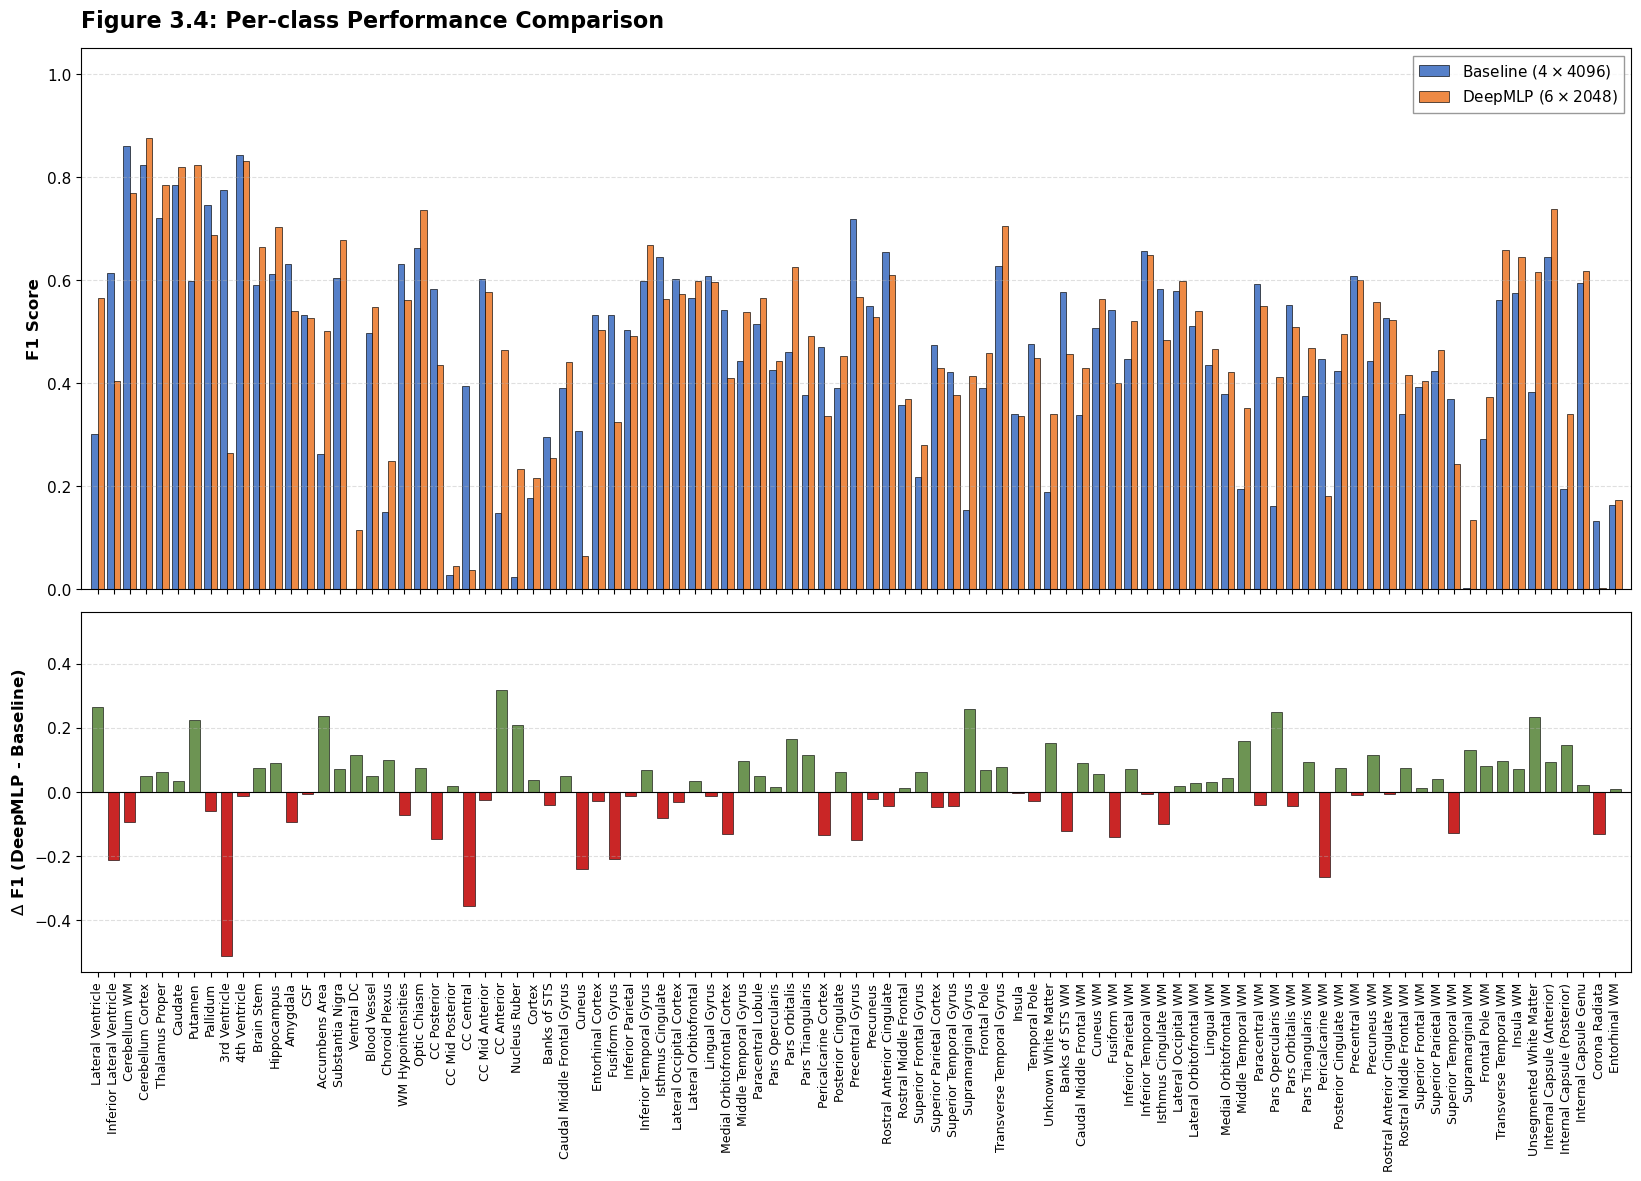

✅ 图表已生成并保存为: Fig3_4_PerClass_Comparison.png


In [ ]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ---------------------------------------------------------
# 1. 完整解剖学名称字典
# ---------------------------------------------------------
class_names = {
    1: "Lateral Ventricle", 2: "Inferior Lateral Ventricle", 3: "Cerebellum WM", 4: "Cerebellum Cortex",
    5: "Thalamus Proper", 6: "Caudate", 7: "Putamen", 8: "Pallidum", 9: "3rd Ventricle",
    10: "4th Ventricle", 11: "Brain Stem", 12: "Hippocampus", 13: "Amygdala", 14: "CSF",
    15: "Accumbens Area", 16: "Substantia Nigra", 17: "Ventral DC", 18: "Blood Vessel", 19: "Choroid Plexus",
    20: "WM Hypointensities", 21: "Optic Chiasm", 22: "CC Posterior", 23: "CC Mid Posterior", 24: "CC Central",
    25: "CC Mid Anterior", 26: "CC Anterior", 27: "Nucleus Ruber", 28: "Cortex", 29: "Banks of STS",
    30: "Caudal Anterior Cingulate", 31: "Caudal Middle Frontal Gyrus", 32: "Cuneus", 33: "Entorhinal Cortex", 34: "Fusiform Gyrus",
    35: "Inferior Parietal", 36: "Inferior Temporal Gyrus", 37: "Isthmus Cingulate", 38: "Lateral Occipital Cortex", 39: "Lateral Orbitofrontal",
    40: "Lingual Gyrus", 41: "Medial Orbitofrontal Cortex", 42: "Middle Temporal Gyrus", 43: "Parahippocampal Gyrus", 44: "Paracentral Lobule",
    45: "Pars Opercularis", 46: "Pars Orbitalis", 47: "Pars Triangularis", 48: "Pericalcarine Cortex", 49: "Postcentral Gyrus",
    50: "Posterior Cingulate", 51: "Precentral Gyrus", 52: "Precuneus", 53: "Rostral Anterior Cingulate", 54: "Rostral Middle Frontal",
    55: "Superior Frontal Gyrus", 56: "Superior Parietal Cortex", 57: "Superior Temporal Gyrus", 58: "Supramarginal Gyrus", 59: "Frontal Pole",
    60: "Transverse Temporal Gyrus", 61: "Insula", 62: "Temporal Pole", 63: "Unknown White Matter", 64: "Banks of STS WM",
    65: "Caudal Anterior Cingulate WM", 66: "Caudal Middle Frontal WM", 67: "Cuneus WM", 68: "Fusiform WM", 69: "Inferior Parietal WM",
    70: "Inferior Temporal WM", 71: "Isthmus Cingulate WM", 72: "Lateral Occipital WM", 73: "Lateral Orbitofrontal WM", 74: "Lingual WM",
    75: "Medial Orbitofrontal WM", 76: "Middle Temporal WM", 77: "Parahippocampal WM", 78: "Paracentral WM", 79: "Pars Opercularis WM",
    80: "Pars Orbitalis WM", 81: "Pars Triangularis WM", 82: "Pericalcarine WM", 83: "Postcentral WM", 84: "Posterior Cingulate WM",
    85: "Precentral WM", 86: "Precuneus WM", 87: "Rostral Anterior Cingulate WM", 88: "Rostral Middle Frontal WM", 89: "Superior Frontal WM",
    90: "Superior Parietal WM", 91: "Superior Temporal WM", 92: "Supramarginal WM", 93: "Frontal Pole WM", 94: "Transverse Temporal WM",
    95: "Insula WM", 96: "Unsegmented White Matter", 97: "Internal Capsule (Anterior)", 98: "Internal Capsule (Posterior)", 99: "Internal Capsule Genu",
    100: "Corona Radiata", 101: "Entorhinal WM"
}
sorted_ids = sorted(class_names.keys())

# ---------------------------------------------------------
# 2. 读取 Baseline 数据 (从 JSON 中挑选最佳 Fold)
# ---------------------------------------------------------
def load_best_baseline(json_path, target_f1=0.438):
    """
    读取 JSON 文件，找到 Macro-F1 最接近 target_f1 (43.8%) 的 Fold，
    并提取其 Per-class F1 数据。
    """
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    best_idx = -1
    min_diff = float('inf')
    
    # 寻找最佳 Fold
    for i, entry in enumerate(data):
        try:
            f1 = entry['metrics']['passes']['initial']['test_metrics']['macro_f1']
            diff = abs(f1 - target_f1)
            if diff < min_diff:
                min_diff = diff
                best_idx = i
        except:
            continue
            
    if best_idx == -1:
        print("Error: 无法从 JSON 中解析出有效数据")
        return None

    best_entry = data[best_idx]
    print(f"✅ 选定的 Baseline Fold: {best_entry['fold_name']}")
    print(f"✅ Baseline Macro-F1: {best_entry['metrics']['passes']['initial']['test_metrics']['macro_f1']:.4f} (目标: {target_f1})")
    
    # 提取 Per-class F1
    per_class_metrics = best_entry['metrics']['passes']['initial']['test_metrics']['per_class']
    
    baseline_f1_map = {}
    for cid_str, metrics in per_class_metrics.items():
        baseline_f1_map[int(cid_str)] = metrics['f1']
        
    return baseline_f1_map

# 加载 Baseline 数据
# ⚠️ 确保你的 JSON 文件名正确
baseline_path = '/Users/jannik/KAN-Brain-Single-Voxel-Segmentaion/论文复现/论文图片/All_Per_Class_Metrics_Summary.json' 
baseline_map = load_best_baseline(baseline_path)

# ---------------------------------------------------------
# 3. 读取 DeepMLP 数据 (保留你的原有逻辑)
# ---------------------------------------------------------
# ⚠️ 请确保此路径指向你本地真实的 DeepMLP 报告文件
deepmlp_file_path = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/图3.4  gc f1 history/deepmlptest_evaluation_report.txt'

def parse_report_full(filename):
    data = {} # 使用字典方便按 ID 查找 {id: f1}
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            text = f.read()
        start_marker = "每个类别的详细指标:"
        idx = text.find(start_marker)
        if idx != -1:
            table_text = text[idx:]
            # 正则匹配: ID ... F1 (捕获 ID 和 F1)
            pattern = re.compile(r"^\s*(\d+)\s+\d+\s+[0-9\.]+\S*\s+[0-9\.]+\S*\s+([0-9\.]+)", re.MULTILINE)
            matches = pattern.findall(table_text)
            for pid, f1 in matches:
                data[int(pid)] = float(f1)
    except FileNotFoundError:
        print(f"❌ 错误: 找不到文件 {filename}")
        return {}
    return data

deepmlp_map = parse_report_full(deepmlp_file_path)

if not deepmlp_map:
    print("❌ DeepMLP 数据读取失败，请检查路径。")
    # 为了防止代码崩溃，如果没有读到数据，这里可以由你决定是否终止
    # raise ValueError("No DeepMLP data") 
else:
    print(f"✅ DeepMLP 数据读取成功，包含 {len(deepmlp_map)} 个类别")

# ---------------------------------------------------------
# 4. 数据对齐与绘图
# ---------------------------------------------------------
if baseline_map and deepmlp_map:
    # 准备绘图数组（确保 ID 顺序一致）
    plot_ids = []
    plot_names = []
    arr_baseline = []
    arr_deepmlp = []
    
    for cid in sorted_ids:
        # 只取两个模型都存在的类别
        if cid in baseline_map and cid in deepmlp_map:
            plot_ids.append(cid)
            plot_names.append(class_names[cid])
            arr_baseline.append(baseline_map[cid])
            arr_deepmlp.append(deepmlp_map[cid])
            
    arr_baseline = np.array(arr_baseline)
    arr_deepmlp = np.array(arr_deepmlp)
    
    # 计算 Delta
    arr_delta = arr_deepmlp - arr_baseline
    
    # --- 开始绘图 ---
    plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 11})
    
    fig = plt.figure(figsize=(20, 12)) 
    gs = gridspec.GridSpec(2, 1, height_ratios=[1.5, 1], hspace=0.05)
    
    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1], sharex=ax1)
    
    x = np.arange(len(plot_names))
    width = 0.4
    
    # 上图: 绝对值对比
    ax1.bar(x - width/2, arr_baseline, width, label='Baseline ($4\\times4096$)', color='#4472C4', edgecolor='black', linewidth=0.5, alpha=0.9)
    ax1.bar(x + width/2, arr_deepmlp, width, label='DeepMLP ($6\\times2048$)', color='#ED7D31', edgecolor='black', linewidth=0.5, alpha=0.9)
    ax1.set_ylabel('F1 Score', fontweight='bold', fontsize=12)
    ax1.set_title('Figure 3.4: Per-class Performance Comparison', loc='left', fontsize=16, fontweight='bold', pad=15)
    ax1.legend(loc='upper right', frameon=True, edgecolor='gray', fancybox=False)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    ax1.set_ylim(0, 1.05)
    plt.setp(ax1.get_xticklabels(), visible=False)
    
    # 下图: Delta 差异
    colors = ['#548235' if v >= 0 else '#C00000' for v in arr_delta]
    ax2.bar(x, arr_delta, width=0.7, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('$\Delta$ F1 (DeepMLP - Baseline)', fontweight='bold', fontsize=12)
    ax2.grid(axis='y', linestyle='--', alpha=0.4)
    
    # 自动调整 Y 轴范围
    max_val = max(abs(np.min(arr_delta)), abs(np.max(arr_delta))) * 1.1
    ax2.set_ylim(-max_val, max_val)
    
    # 设置 X 轴
    ax2.set_xticks(x)
    ax2.set_xticklabels(plot_names, rotation=90, ha='center', fontsize=9)
    ax2.set_xlim(-1, len(plot_names))
    
    plt.tight_layout()
    save_filename = 'Fig3_4_PerClass_Comparison.png'
    # plt.savefig(save_filename, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✅ 图表已生成并保存为: {save_filename}")

/var/folders/kr/c215w16n7756009kd5l3llzm0000gn/T/ipykernel_8313/3994795732.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


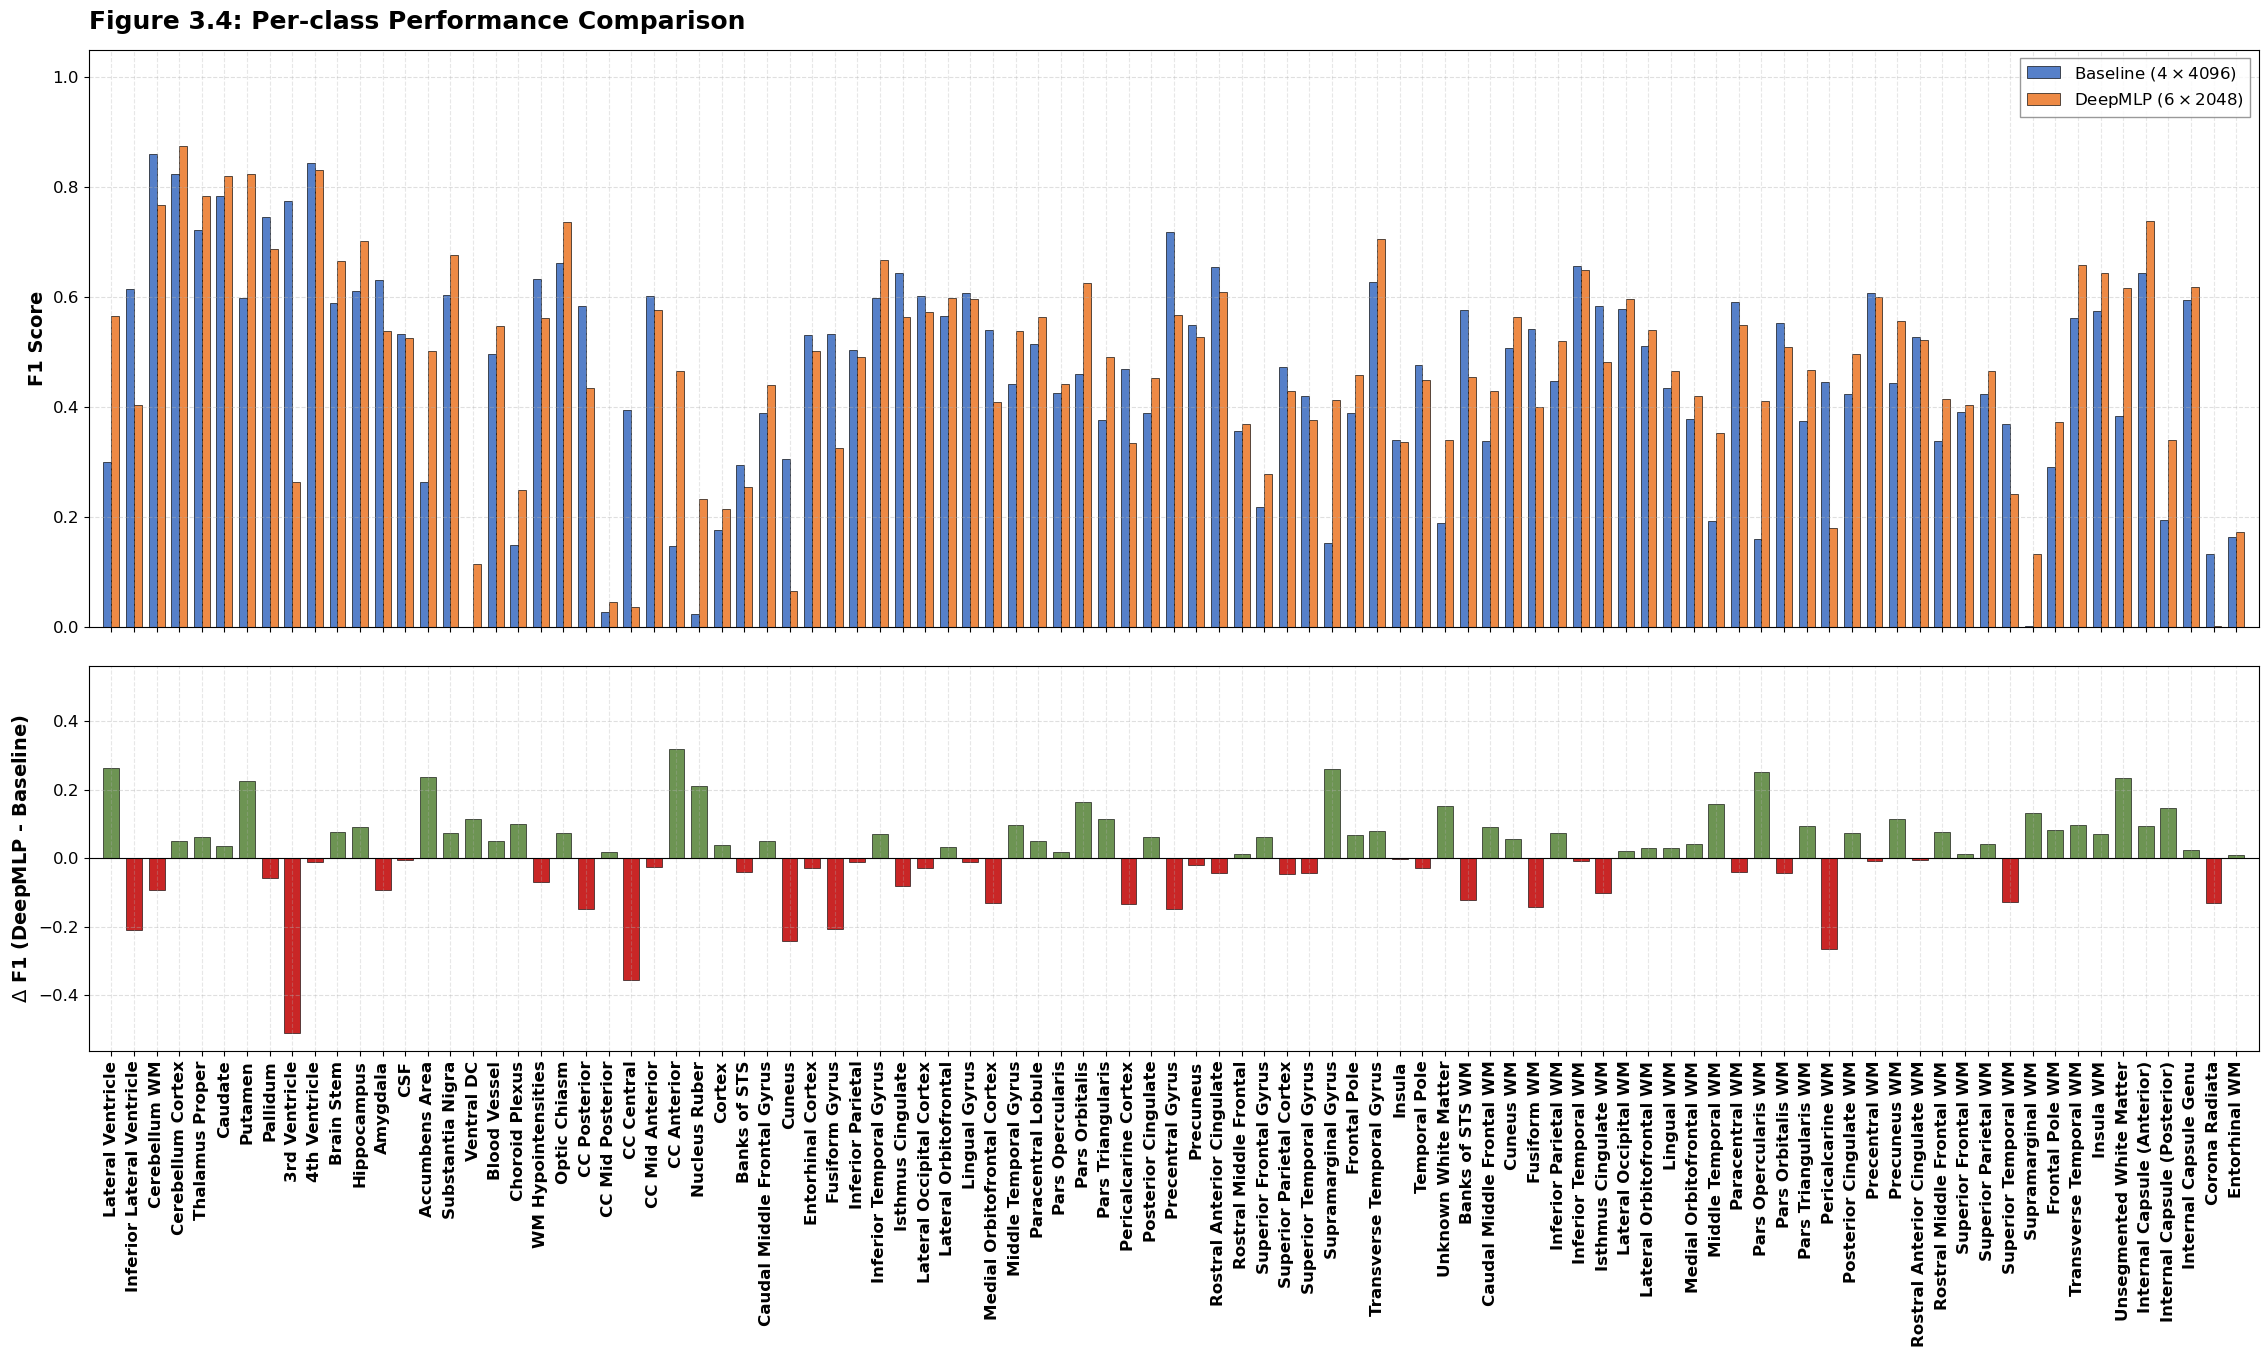

✅ 图表已生成，标签已加粗加大。


In [6]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ... (前半部分: 字典定义、数据读取函数保持不变，为节省篇幅省略，请确保保留之前的定义代码) ...
# 为了方便你直接运行，这里假设 baseline_map 和 deepmlp_map 已经读取好了
# 如果你需要完整的一体化代码，请告诉我，我再贴一次全文。

# =========================================================
# 4. 数据对齐与绘图 (重点修改了这一部分)
# =========================================================
if baseline_map and deepmlp_map:
    plot_ids = []
    plot_names = []
    arr_baseline = []
    arr_deepmlp = []
    
    for cid in sorted_ids:
        if cid in baseline_map and cid in deepmlp_map:
            plot_ids.append(cid)
            plot_names.append(class_names[cid])
            arr_baseline.append(baseline_map[cid])
            arr_deepmlp.append(deepmlp_map[cid])
            
    arr_baseline = np.array(arr_baseline)
    arr_deepmlp = np.array(arr_deepmlp)
    arr_delta = arr_deepmlp - arr_baseline
    
    # [教学]: 这里控制全局字体风格
    # 'sans-serif' 是无衬线字体(类似 Arial)，'serif' 是衬线字体(类似 Times New Roman)
    # 硕士论文通常推荐用 'serif' 配合 Times New Roman 风格，这里我先设为通用风格
    plt.rcParams.update({
        'font.family': 'sans-serif', 
        'font.size': 12  # 全局基础字号稍微调大
    })
    
    # 画布维持加宽状态
    fig = plt.figure(figsize=(28, 13)) 
    
    gs = gridspec.GridSpec(2, 1, height_ratios=[1.5, 1], hspace=0.08) # hspace 稍微拉大一点防止重叠
    
    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1], sharex=ax1)
    
    x = np.arange(len(plot_names))
    width = 0.35 
    
    # 上图
    ax1.bar(x - width/2, arr_baseline, width, label='Baseline ($4\\times4096$)', color='#4472C4', edgecolor='black', linewidth=0.5, alpha=0.9)
    ax1.bar(x + width/2, arr_deepmlp, width, label='DeepMLP ($6\\times2048$)', color='#ED7D31', edgecolor='black', linewidth=0.5, alpha=0.9)
    ax1.set_ylabel('F1 Score', fontweight='bold', fontsize=14)
    ax1.set_title('Figure 3.4: Per-class Performance Comparison', loc='left', fontsize=18, fontweight='bold', pad=15)
    ax1.legend(loc='upper right', frameon=True, edgecolor='gray', fancybox=False, fontsize=12)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    ax1.set_ylim(0, 1.05)
    plt.setp(ax1.get_xticklabels(), visible=False)
    
    # 下图
    colors = ['#548235' if v >= 0 else '#C00000' for v in arr_delta]
    ax2.bar(x, arr_delta, width=0.7, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('$\Delta$ F1 (DeepMLP - Baseline)', fontweight='bold', fontsize=14)
    ax2.grid(axis='y', linestyle='--', alpha=0.4)
    
    max_val = max(abs(np.min(arr_delta)), abs(np.max(arr_delta))) * 1.1
    ax2.set_ylim(-max_val, max_val)
    
    # [修改点]: 设置 X 轴标签样式
    ax2.set_xticks(x)
    ax2.set_xticklabels(plot_names, 
                        rotation=90, 
                        ha='center', 
                        fontsize=12,       # <--- 这里调大小 (之前是9，现在是12)
                        fontweight='bold'  # <--- 这里调粗细 (加粗)
                       )
    ax2.set_xlim(-1, len(plot_names))
    
    plt.tight_layout()
    save_filename = 'Fig3_4_Bold_Labels.png'
    # plt.savefig(save_filename, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✅ 图表已生成，标签已加粗加大。")

/var/folders/kr/c215w16n7756009kd5l3llzm0000gn/T/ipykernel_11147/4089816816.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


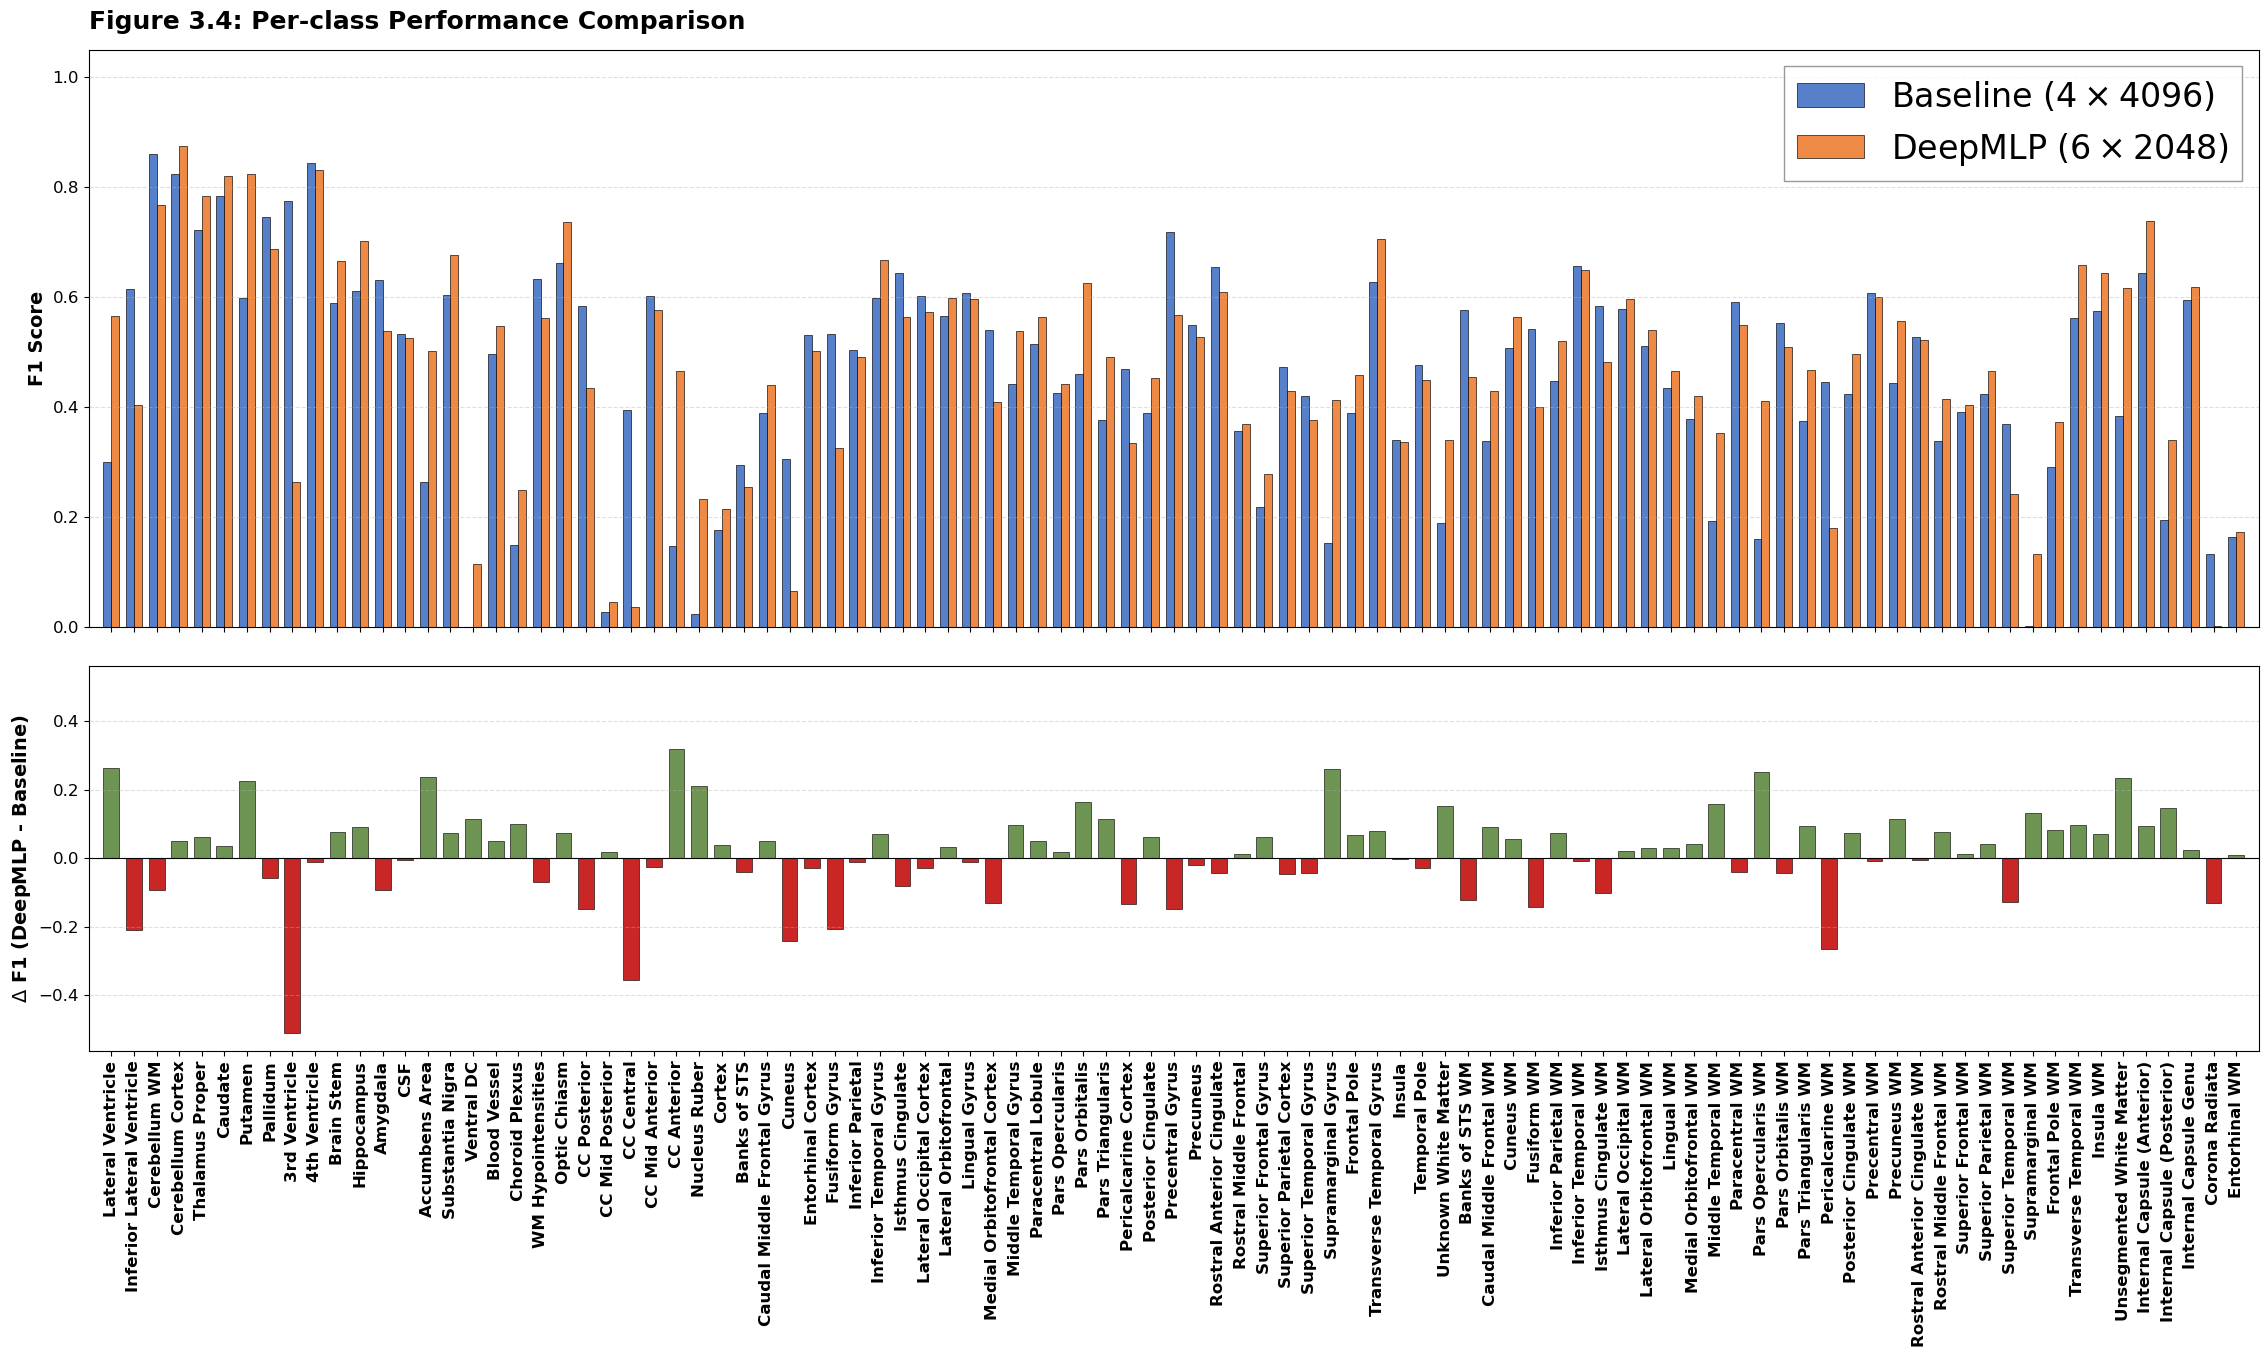

✅ 图表已生成，Legend 已放大。


In [1]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ---------------------------------------------------------
# 1. 完整解剖学名称字典 (保持不变)
# ---------------------------------------------------------
class_names = {
    1: "Lateral Ventricle", 2: "Inferior Lateral Ventricle", 3: "Cerebellum WM", 4: "Cerebellum Cortex",
    5: "Thalamus Proper", 6: "Caudate", 7: "Putamen", 8: "Pallidum", 9: "3rd Ventricle",
    10: "4th Ventricle", 11: "Brain Stem", 12: "Hippocampus", 13: "Amygdala", 14: "CSF",
    15: "Accumbens Area", 16: "Substantia Nigra", 17: "Ventral DC", 18: "Blood Vessel", 19: "Choroid Plexus",
    20: "WM Hypointensities", 21: "Optic Chiasm", 22: "CC Posterior", 23: "CC Mid Posterior", 24: "CC Central",
    25: "CC Mid Anterior", 26: "CC Anterior", 27: "Nucleus Ruber", 28: "Cortex", 29: "Banks of STS",
    30: "Caudal Anterior Cingulate", 31: "Caudal Middle Frontal Gyrus", 32: "Cuneus", 33: "Entorhinal Cortex", 34: "Fusiform Gyrus",
    35: "Inferior Parietal", 36: "Inferior Temporal Gyrus", 37: "Isthmus Cingulate", 38: "Lateral Occipital Cortex", 39: "Lateral Orbitofrontal",
    40: "Lingual Gyrus", 41: "Medial Orbitofrontal Cortex", 42: "Middle Temporal Gyrus", 43: "Parahippocampal Gyrus", 44: "Paracentral Lobule",
    45: "Pars Opercularis", 46: "Pars Orbitalis", 47: "Pars Triangularis", 48: "Pericalcarine Cortex", 49: "Postcentral Gyrus",
    50: "Posterior Cingulate", 51: "Precentral Gyrus", 52: "Precuneus", 53: "Rostral Anterior Cingulate", 54: "Rostral Middle Frontal",
    55: "Superior Frontal Gyrus", 56: "Superior Parietal Cortex", 57: "Superior Temporal Gyrus", 58: "Supramarginal Gyrus", 59: "Frontal Pole",
    60: "Transverse Temporal Gyrus", 61: "Insula", 62: "Temporal Pole", 63: "Unknown White Matter", 64: "Banks of STS WM",
    65: "Caudal Anterior Cingulate WM", 66: "Caudal Middle Frontal WM", 67: "Cuneus WM", 68: "Fusiform WM", 69: "Inferior Parietal WM",
    70: "Inferior Temporal WM", 71: "Isthmus Cingulate WM", 72: "Lateral Occipital WM", 73: "Lateral Orbitofrontal WM", 74: "Lingual WM",
    75: "Medial Orbitofrontal WM", 76: "Middle Temporal WM", 77: "Parahippocampal WM", 78: "Paracentral WM", 79: "Pars Opercularis WM",
    80: "Pars Orbitalis WM", 81: "Pars Triangularis WM", 82: "Pericalcarine WM", 83: "Postcentral WM", 84: "Posterior Cingulate WM",
    85: "Precentral WM", 86: "Precuneus WM", 87: "Rostral Anterior Cingulate WM", 88: "Rostral Middle Frontal WM", 89: "Superior Frontal WM",
    90: "Superior Parietal WM", 91: "Superior Temporal WM", 92: "Supramarginal WM", 93: "Frontal Pole WM", 94: "Transverse Temporal WM",
    95: "Insula WM", 96: "Unsegmented White Matter", 97: "Internal Capsule (Anterior)", 98: "Internal Capsule (Posterior)", 99: "Internal Capsule Genu",
    100: "Corona Radiata", 101: "Entorhinal WM"
}
sorted_ids = sorted(class_names.keys())

# ---------------------------------------------------------
# 2. 读取 Baseline 数据
# ---------------------------------------------------------
# ⚠️ 确保路径正确
baseline_path = 'All_Per_Class_Metrics_Summary.json' 

def load_best_baseline(json_path, target_f1=0.438):
    with open(json_path, 'r') as f:
        data = json.load(f)
    best_idx = -1
    min_diff = float('inf')
    for i, entry in enumerate(data):
        try:
            f1 = entry['metrics']['passes']['initial']['test_metrics']['macro_f1']
            diff = abs(f1 - target_f1)
            if diff < min_diff:
                min_diff = diff
                best_idx = i
        except:
            continue
    if best_idx == -1:
        return {}
    
    per_class_metrics = data[best_idx]['metrics']['passes']['initial']['test_metrics']['per_class']
    baseline_f1_map = {}
    for cid_str, metrics in per_class_metrics.items():
        baseline_f1_map[int(cid_str)] = metrics['f1']
    return baseline_f1_map

baseline_map = load_best_baseline(baseline_path)

# ---------------------------------------------------------
# 3. 读取 DeepMLP 数据 (保留原逻辑)
# ---------------------------------------------------------
# ⚠️ 确保路径正确
deepmlp_file_path = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/data/图3.4  gc f1 history/deepmlptest_evaluation_report.txt'

def parse_report_full(filename):
    data = {}
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            text = f.read()
        start_marker = "每个类别的详细指标:"
        idx = text.find(start_marker)
        if idx != -1:
            table_text = text[idx:]
            pattern = re.compile(r"^\s*(\d+)\s+\d+\s+[0-9\.]+\S*\s+[0-9\.]+\S*\s+([0-9\.]+)", re.MULTILINE)
            matches = pattern.findall(table_text)
            for pid, f1 in matches:
                data[int(pid)] = float(f1)
    except FileNotFoundError:
        print(f"❌ 错误: 找不到文件 {filename} (如果需要请在此处插入你的Mock数据逻辑)")
        return {}
    return data

deepmlp_map = parse_report_full(deepmlp_file_path)

# =========================================================
# 4. 绘图 (这里包含了所有的样式修改)
# =========================================================
if baseline_map and deepmlp_map:
    plot_ids = []
    plot_names = []
    arr_baseline = []
    arr_deepmlp = []
    
    for cid in sorted_ids:
        if cid in baseline_map and cid in deepmlp_map:
            plot_ids.append(cid)
            plot_names.append(class_names[cid])
            arr_baseline.append(baseline_map[cid])
            arr_deepmlp.append(deepmlp_map[cid])
            
    arr_baseline = np.array(arr_baseline)
    arr_deepmlp = np.array(arr_deepmlp)
    arr_delta = arr_deepmlp - arr_baseline
    
    # 字体设置
    plt.rcParams.update({
        'font.family': 'sans-serif', 
        'font.size': 12
    })
    
    # 画布设置
    fig = plt.figure(figsize=(28, 13)) 
    gs = gridspec.GridSpec(2, 1, height_ratios=[1.5, 1], hspace=0.08)
    
    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1], sharex=ax1)
    
    x = np.arange(len(plot_names))
    width = 0.35 
    
    # 上图绘制
    ax1.bar(x - width/2, arr_baseline, width, label='Baseline ($4\\times4096$)', color='#4472C4', edgecolor='black', linewidth=0.5, alpha=0.9)
    ax1.bar(x + width/2, arr_deepmlp, width, label='DeepMLP ($6\\times2048$)', color='#ED7D31', edgecolor='black', linewidth=0.5, alpha=0.9)
    ax1.set_ylabel('F1 Score', fontweight='bold', fontsize=14)
    ax1.set_title('Figure 3.4: Per-class Performance Comparison', loc='left', fontsize=18, fontweight='bold', pad=15)
    
    # [关键修改]: 这里将 fontsize 设为 24 (放大2倍)
    ax1.legend(loc='upper right', frameon=True, edgecolor='gray', fancybox=False, fontsize=24)
    
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    ax1.set_ylim(0, 1.05)
    plt.setp(ax1.get_xticklabels(), visible=False)
    
    # 下图绘制
    colors = ['#548235' if v >= 0 else '#C00000' for v in arr_delta]
    ax2.bar(x, arr_delta, width=0.7, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('$\Delta$ F1 (DeepMLP - Baseline)', fontweight='bold', fontsize=14)
    ax2.grid(axis='y', linestyle='--', alpha=0.4)
    
    max_val = max(abs(np.min(arr_delta)), abs(np.max(arr_delta))) * 1.1
    ax2.set_ylim(-max_val, max_val)
    
    # X轴标签样式 (加粗加大)
    ax2.set_xticks(x)
    ax2.set_xticklabels(plot_names, rotation=90, ha='center', fontsize=12, fontweight='bold')
    ax2.set_xlim(-1, len(plot_names))
    
    plt.tight_layout()
    save_filename = 'Fig3_4_Large_Legend.png'
    plt.savefig(save_filename, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✅ 图表已生成，Legend 已放大。")